In [2]:
import demes
import scipy
import pickle
import demesdraw
import sparse

import numpy as np
import matplotlib.pyplot as plt

import sys

from momi3.Params import Params
from momi3.MOMI import Momi

/home/enesdilber/momi3/src/momi3/utils.py:23: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
import jax
jax.devices()

[CpuDevice(id=0)]

In [4]:
b = demes.Builder()
b.add_deme("ABC", epochs = [dict(start_size = 1200, end_time = 800)])
b.add_deme("AB", ancestors = ["ABC"], epochs = [dict(start_size = 1000, end_time = 550)])
b.add_deme("C", ancestors = ["ABC"], epochs = [dict(start_size = 300)])
b.add_deme("A", ancestors = ["AB"], epochs = [dict(start_size = 800)])
b.add_deme("B", ancestors = ["AB"], epochs = [dict(start_size = 700)])
b.add_pulse(sources = ["C"], dest = "B", time = 240, proportions = [0.28])
g = b.resolve()

In [5]:
sampled_demes = ["A", "B", "C"]
sample_sizes = [5, 4, 7]

momi = Momi(g, sampled_demes=sampled_demes, sample_sizes=sample_sizes, low_memory=False)
params = momi._default_params

In [6]:
params.set_train_all_etas(True)
params.set_train('eta_0', False)

In [7]:
jsfs = momi.simulate(2000, seed=1124321)

  0%|          | 0/2000 [00:00<?, ?it/s]

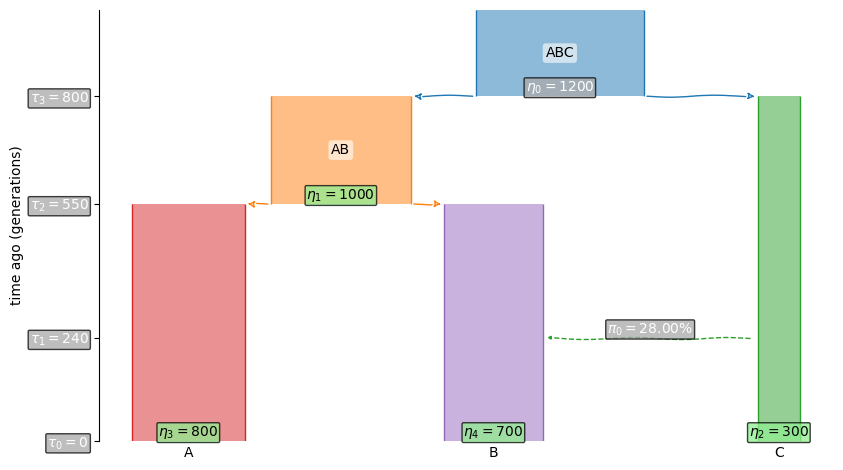

In [8]:
# We will infer greens
params.tubes(show_values=True, show_letters=True, log_time=False)

First run took 1.08 seconds


  0%|          | 0/5 [00:00<?, ?it/s]

loglik=-1642.2
Values: eta_1=1e+03, eta_2=2.3e+02, eta_3=7.9e+02, eta_4=6.8e+02
loglik=-1633.1
Values: eta_1=1e+03, eta_2=1.8e+02, eta_3=7.7e+02, eta_4=6.7e+02
loglik=-1630.2
Values: eta_1=9.9e+02, eta_2=1.7e+02, eta_3=7.6e+02, eta_4=6.4e+02
loglik=-1627
Values: eta_1=9.9e+02, eta_2=1.7e+02, eta_3=7.4e+02, eta_4=6.2e+02
loglik=-1623.2
Values: eta_1=9.8e+02, eta_2=1.7e+02, eta_3=7.2e+02, eta_4=5.9e+02


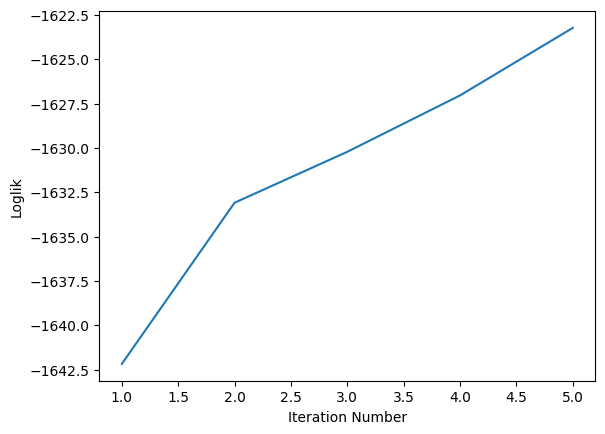

In [14]:
# monitoring training
ret = momi.optimize(params=params, jsfs=jsfs, stepsize=1e5, maxiter=5, monitor_training=True)

In [15]:
# set optimized values to params

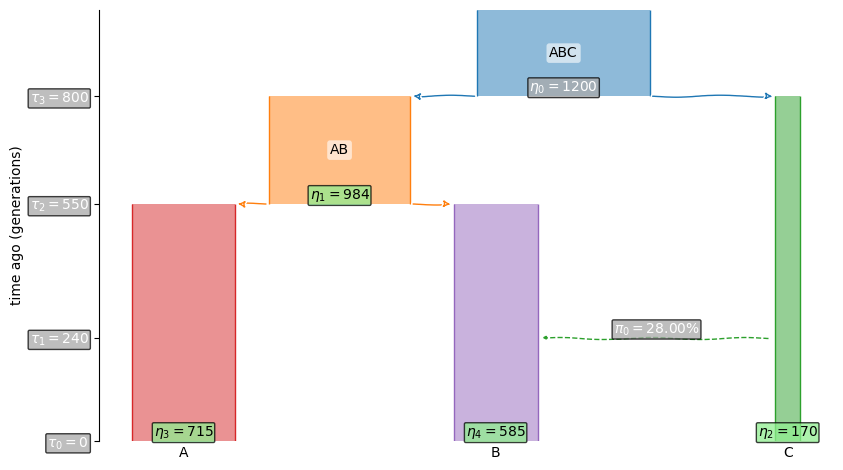

In [16]:
params.set_optimization_results(ret.theta_train_hat)
params.tubes(show_values=True, show_letters=True, log_time=False)

# Likelihood Calculation
You can only calculate likelihood for a given parameter values

In [17]:
params.set_train_all(False)
params.set_train('pi_0', True)

In [18]:
ttd = params.theta_train_dict()

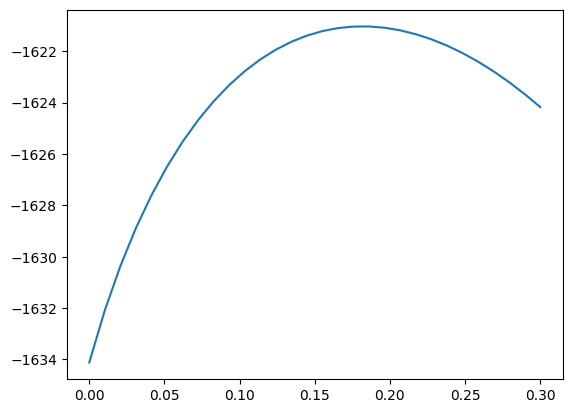

In [19]:
pi_0s = np.linspace(1e-6, 0.3, 30)
logliks = []

for pi_0 in pi_0s:
    ttd['pi_0'] = pi_0
    loglik = momi.loglik(params, jsfs, ttd)
    logliks.append(loglik)

plt.plot(pi_0s, logliks);

In [20]:
params.set('pi_0', 0.1)

## Likelihood and gradient

In [21]:
params.set_train_all(False)
params.set_train_all_etas(True)
params.set_train_all_pis(True)

In [23]:
ttd = params.theta_train_dict()
val, grad = momi.negative_loglik_with_gradient(params, jsfs, ttd) # this function returns -loglik and gradient values